In [1]:
import pandas as pd
import joblib

In [2]:
results_df = joblib.load('../models/results_df.pkl')

In [3]:
rf_model = joblib.load('../models/churn_rf_model.pkl')

In [4]:
results_df

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,...,voice_usage_8,voice_avg_6_7,voice_usage_drop,data_voice_ratio_8,actual_churn,churn_probability,risk_segment,value_segment,customer_segment,recommended_action
3560,7001368948,109,0.0,0.0,0.0,261.154,455.428,741.622,72.31,18.71,...,604.87,641.630,-36.760,0.000000,0,0.073437,Low Risk,Low Value,Low Value - Low Risk,No action required
25643,7000520443,109,0.0,0.0,0.0,905.169,708.586,640.842,47.56,85.26,...,951.72,1117.115,-165.395,0.795806,0,0.152231,Low Risk,Medium Value,Medium Value - Low Risk,No action required
25557,7001808508,109,0.0,0.0,0.0,735.260,586.475,671.356,4.73,4.29,...,1634.42,1409.305,225.115,0.000000,0,0.235302,Low Risk,Medium Value,Medium Value - Low Risk,No action required
22024,7001517339,109,0.0,0.0,0.0,428.944,430.112,528.402,170.43,69.43,...,1413.02,1164.560,248.460,0.000000,0,0.323586,Low Risk,Low Value,Low Value - Low Risk,No action required
9596,7000792852,109,0.0,0.0,0.0,417.224,712.078,436.000,24.63,5.28,...,311.99,305.760,6.230,1.493530,0,0.477849,Medium Risk,Medium Value,Medium Value - Medium Risk,No action required
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28706,7001816899,109,0.0,0.0,0.0,531.320,677.381,662.619,101.18,89.73,...,524.95,814.665,-289.715,2.497994,0,0.408648,Medium Risk,Medium Value,Medium Value - Medium Risk,No action required
23011,7002266419,109,0.0,0.0,0.0,524.869,222.999,71.561,205.01,96.01,...,91.67,658.600,-566.930,0.000000,1,0.932097,High Risk,Low Value,Low Value - High Risk,Minimal intervention
17780,7000102177,109,0.0,0.0,0.0,1406.705,1603.157,1719.877,609.44,670.16,...,2336.54,2774.230,-437.690,0.000000,0,0.166565,Low Risk,High Value,High Value - Low Risk,No action required
28350,7000357552,109,0.0,0.0,0.0,739.750,40.470,0.000,588.64,15.21,...,0.00,691.145,-691.145,0.000000,0,0.957883,High Risk,Low Value,Low Value - High Risk,Minimal intervention


In [5]:
##now implement the ROI calculation

results_df['risk_rank'] = results_df['churn_probability'].rank(ascending=False)

top_20_threshold = int(0.2 * len(results_df))

high_risk_users = results_df.sort_values(
    by="churn_probability",
    ascending=False
).head(top_20_threshold)

In [6]:
## estimating revenue per customer

avg_revenue_per_user = results_df['avg_rech_amt_6_7'].mean()

print("Average revenue per user:", avg_revenue_per_user)

Average revenue per user: 696.7767782775279


In [7]:
## estimate potential revenue saved

potential_churners = high_risk_users['actual_churn'].sum()

revenue_saved = potential_churners * avg_revenue_per_user * 0.30

print("Estimated monthly revenue saved:", revenue_saved)

Estimated monthly revenue saved: 79223.51969015492


In [8]:
## business impact table

total_customers = len(results_df)

high_risk_count = len(high_risk_users)

predicted_churners = high_risk_users['actual_churn'].sum()

retention_rate = 0.30

impact_table = pd.DataFrame({
    "Metric":[
        "Total customers analyzed",
        "Top 20% high-risk users targeted",
        "Predicted churners in this group",
        "Average revenue per user",
        "Retention success assumption",
        "Estimated monthly revenue saved"
    ],
    
    "Value":[
        total_customers,
        high_risk_count,
        predicted_churners,
        round(avg_revenue_per_user,2),
        "30%",
        round(revenue_saved,2)
    ]
})

impact_table

,Metric,Value
0,Total customers analyzed,6003
1,Top 20% high-risk users targeted,1200
2,Predicted churners in this group,379
3,Average revenue per user,696.78
4,Retention success assumption,30%
5,Estimated monthly revenue saved,79223.52


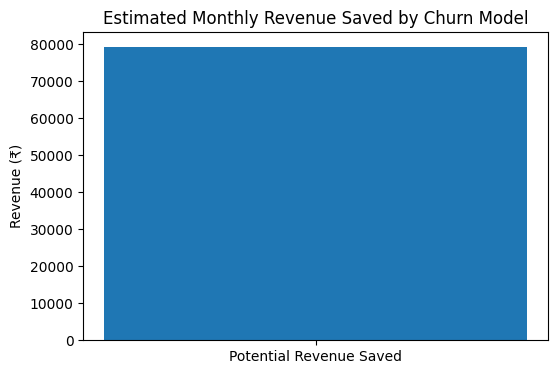

In [9]:
## visula for business impact

import matplotlib.pyplot as plt

labels = ["Potential Revenue Saved"]
values = [revenue_saved]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Estimated Monthly Revenue Saved by Churn Model")
plt.ylabel("Revenue (₹)")

plt.show()

#### By targeting the top 20% of customers with the highest predicted churn probability, the company can potentially save approximately ₹79,000 in monthly revenue.

#### Even if some customers receive retention offers unnecessarily (false positives), the cost of these incentives is small compared to the revenue lost when a high-value customer churns.

In [10]:
results_df.to_csv("../data/final_customer_churn_predictions_with_strategy.csv", index=False)